# User Interface
1. Check if "model.pkl" exists in the same directory as this notebook. If it does, skip to 4, otherwise continue.
2. Run all cells below "[Exploratory Data Analysis](#Exploratory-Data-Analysis)".
3. This can take a while so be patient.
4. Run just "[Load Model and Setup](#Load-Model-and-Setup)"
5. Then run just "[Make Predictions](#Make-Predictions)" for UI display.
6. Re-run "[Make Predictions](#Make-Predictions)" to clear results if needed.



## Load Model and Setup

In [ ]:
from ipywidgets.widgets import trait_types
import ipywidgets as w
import pandas as pd
import numpy as np
import datetime as dt
import pickle
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

model = pickle.load(open("model.pkl", "rb"))

cat = np.zeros(14)
date = w.DatePicker(description='Date:', value=dt.date.today())
category = w.Dropdown(description='Category:',
    options=[
        ('Entertainment', 0),
        ('Food/Dining', 1),
        ('Transportation', 2),
        ('Grocery (Internet)', 3),
        ('Grocery (In-Store)', 4),
        ('Health and Fitness', 5),
        ('Home', 6),
        ('Kids and Pets', 7),
        ('Miscellaneous (Internet)', 8),
        ('Miscellaneous (In-Store)', 9),
        ('Personal Care', 10),
        ('Internet Shopping', 11),
        ('In-Store Shopping', 12),
        ('Travel', 13)
    ]
)
amount = w.FloatText(description='Amount ($):', min=0, value=13.37)
age = w.BoundedIntText(description='Age:', min=18, max=120)
last_30_days = w.BoundedIntText(description='Number of Transactions in Last 30 Days:', min=0, max=400, 
                                style={'description_width': 'initial'})
time = w.IntSlider(description='Time (Hour):', min=0, max=23)
zip = w.BoundedIntText(description='Zip Code:', value=90210, max=99999)
button = w.Button(description='Predict', tooltip='Click to get prediction!')
heading = w.HTML(value='<h2>Transaction Information</h2>')
result_label = w.Label(value="")

def on_button_clicked(b):
  transaction = np.array([amount.value,
                          int(time.value < 4 or time.value > 21),
                          last_30_days.value,
                          time.value,
                          date.value.month,
                          age.value,
                          int(date.value.weekday() == 0 or date.value.weekday() == 6),
                          zip.value])
  cat[category.value] = 1
  transaction = np.concatenate((transaction, cat))
  pred = model.predict_proba(transaction.reshape(1, -1))
  # Replace print(...) with:
  result_label.value = f'Transaction has a {pred[0][0] * 100:.0f}% chance of being legitimate.'


button.on_click(on_button_clicked)

ui = w.VBox([heading, date, time, category, amount, age, last_30_days, zip, button, result_label])

## Make Predictions

In [36]:
from IPython.display import display
display(ui)

# Exploratory Data Analysis

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import datetime as dt
import pickle

%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## Get Data

In [4]:
# !gdown "1yq4KrvL-uw0uIKSy2Ob86BLeKyt-kHrP&confirm=t"
# !gdown "15k1ylbRg1cVxWfkszQE2g7sPEVPpceiG&confirm=t"
df = pd.read_csv('fraudTrain.csv')
test = pd.read_csv('fraudTest.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)
test.drop('Unnamed: 0', axis=1, inplace=True)
df.shape
test.shape

(555719, 22)

### Clean Data

In [5]:
df.isna().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

No empty cells found.

## Feature Selection

### Inital Correlation Matrix

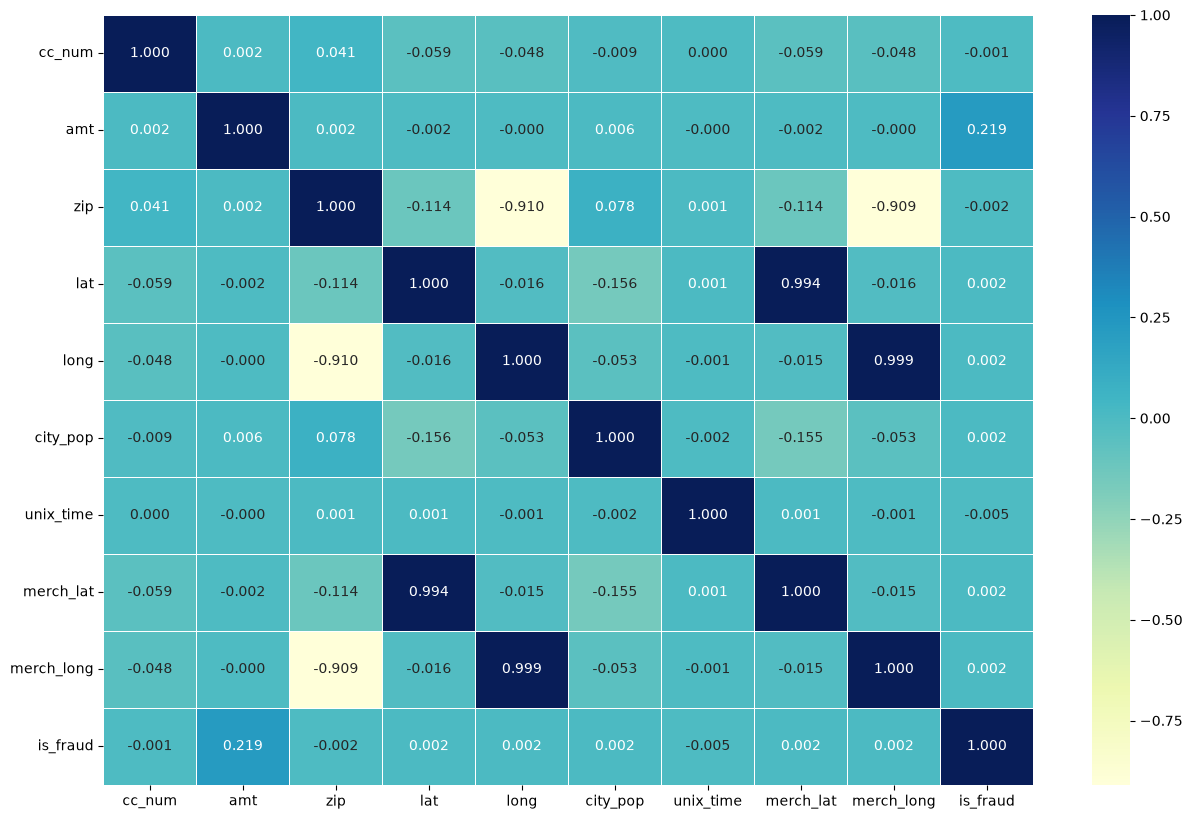

In [6]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5, fmt= ".3f", cmap="YlGnBu");

Results indicate:
* only `amt` has decent correlation
* `lat` and `long` overlap with `merch_lat` and `merch_long`
* will have to derive new features



In [7]:
X = df.drop(['merch_lat', 'merch_long'], axis=1)

### Checking Columns

In [8]:
df.dtypes

trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [9]:
df.nunique()

trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
dtype: int64

### Dropping Categorigal Features with High Cardinality
* except a few to use for transformations

In [10]:
X.drop(['merchant', 'first', 'last', 'street', 'city', 'state', 'job', 'trans_num'], axis=1, inplace=True)
X.dtypes

trans_date_trans_time        str
cc_num                     int64
category                     str
amt                      float64
gender                       str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
dob                          str
unix_time                  int64
is_fraud                   int64
dtype: object

### Checking Gender

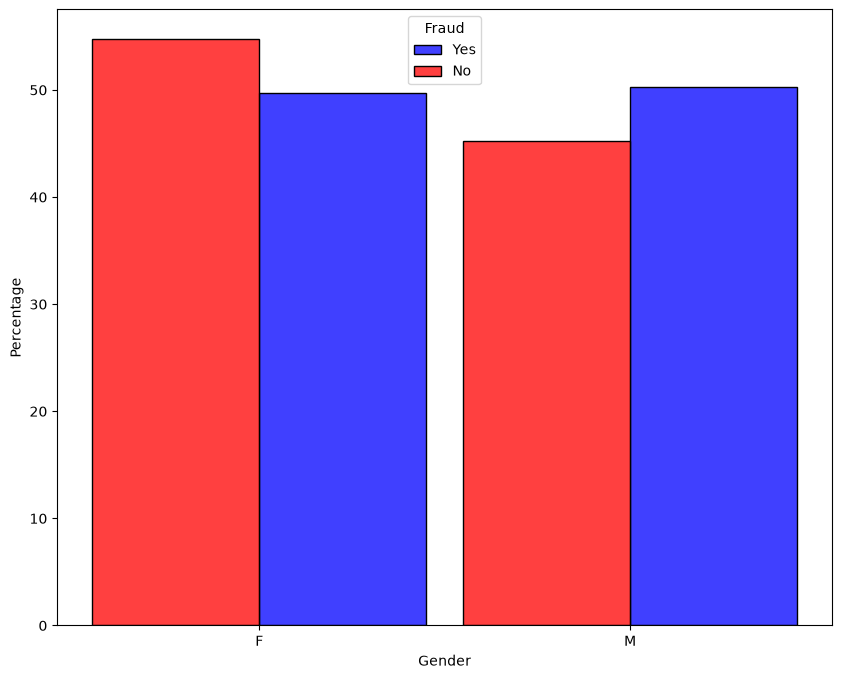

In [11]:
plt.figure(figsize=(10,8))
ax = sns.histplot(x='gender', data=df, hue='is_fraud', stat='percent', multiple='dodge', common_norm=False, shrink=0.9,
                  palette=["red", "blue"])
ax.set_ylabel('Percentage')
ax.set_xlabel('Gender')
plt.legend(title='Fraud', labels=['Yes', 'No'], loc="upper center");

`gender` looks to have little impact on fraud. Dropping column.

In [12]:
X.drop(['gender'], axis=1, inplace=True)

### Checking Amount

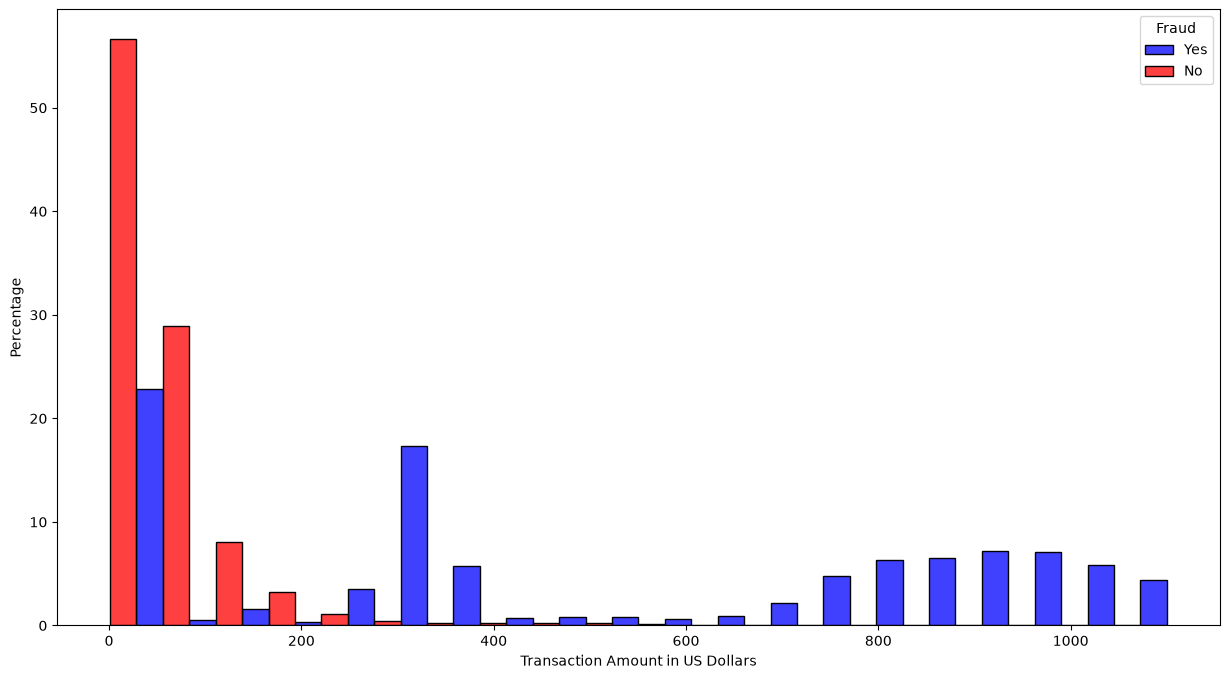

In [13]:
plt.figure(figsize=(15,8))
ax=sns.histplot(x='amt' ,data=df[df.amt < 1100], hue='is_fraud', stat='percent', multiple='dodge',
                common_norm=False, bins=20, palette=['red', 'blue'])
ax.set_ylabel('Percentage')
ax.set_xlabel('Transaction Amount in US Dollars')
plt.legend(title='Fraud', labels=['Yes', 'No']);

`amt` has the highest correlation so this is no surprise.

### Checking Category

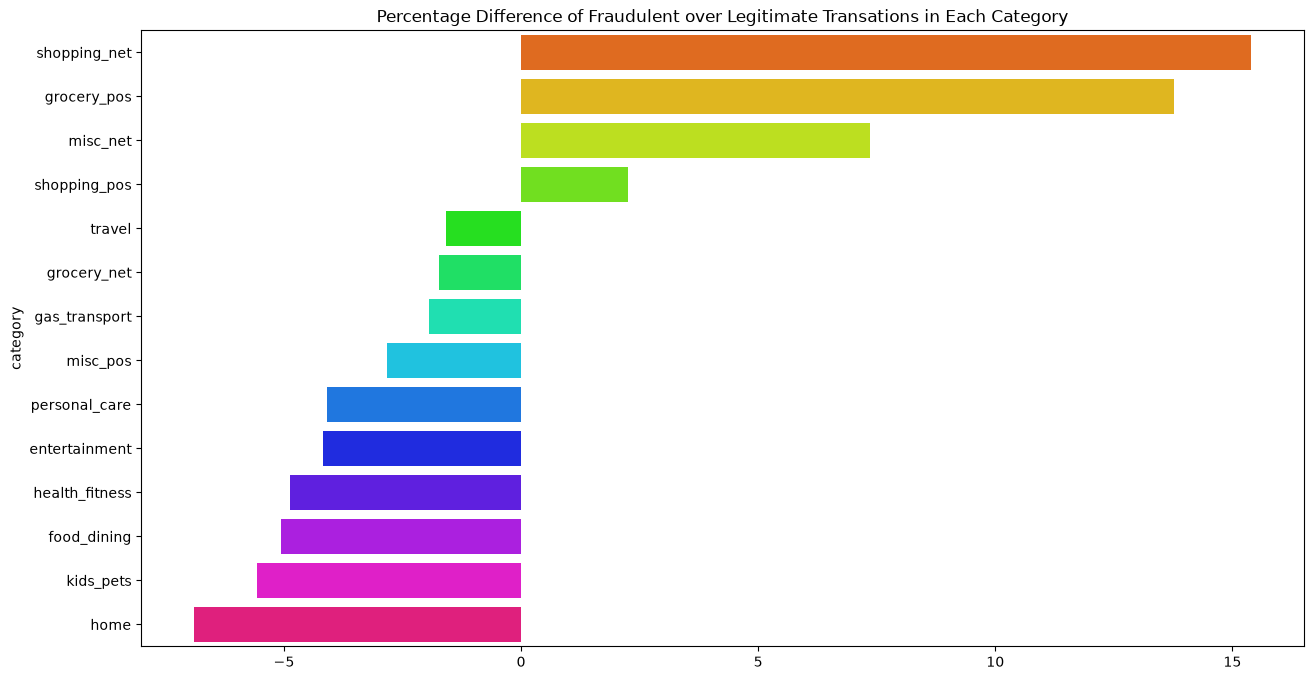

In [14]:
plt.figure(figsize=(15,8))
yes = df[df['is_fraud']== 1]['category']
no = df[df['is_fraud']== 0]['category']
a = yes.value_counts(normalize=True)
b = no.value_counts(normalize=True)
c = (a - b) * 100
c = c.sort_values(ascending=False)
categories = c.index
freq = c.values
ax = sns.barplot(y=categories, x=freq, palette='hsv')
plt.title('Percentage Difference of Fraudulent over Legitimate Transations in Each Category');

`category` is significant as well. This will need to be encoded before training.

### Add Features

In [15]:
X['hour'] = pd.to_datetime(df.trans_date_trans_time).dt.hour

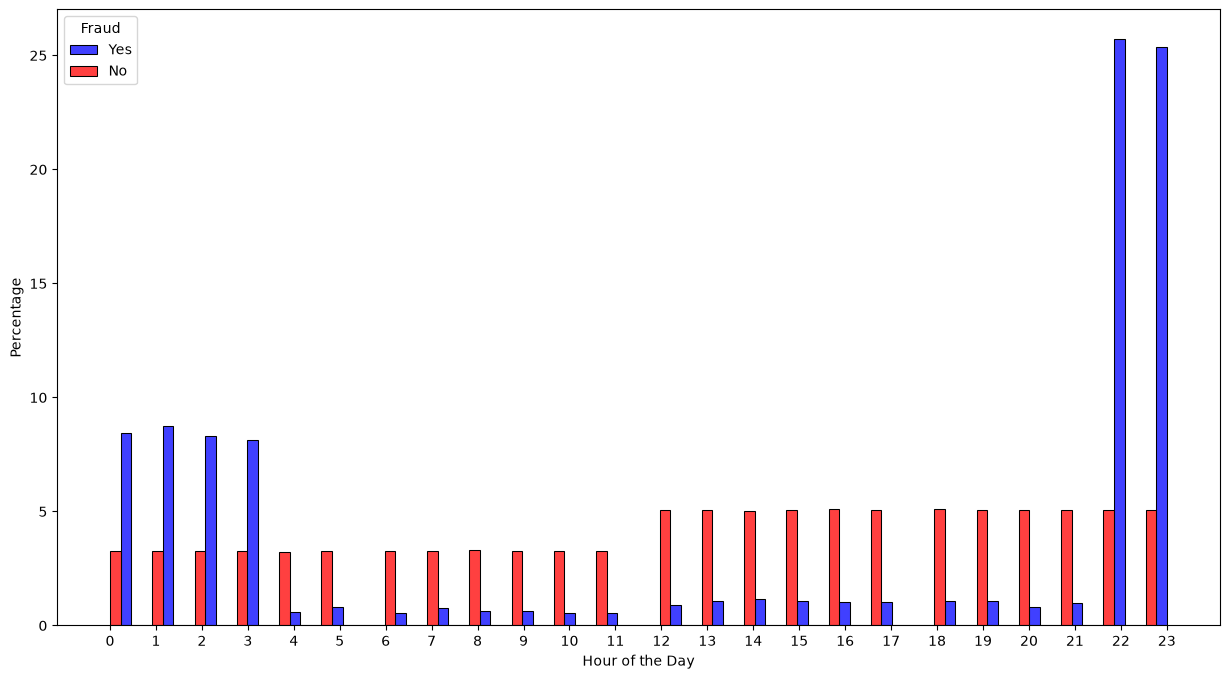

In [16]:
plt.figure(figsize=(15,8))
ax = sns.histplot(data=X, x="hour", hue="is_fraud", common_norm=False, bins=50,
                stat='percent', multiple='dodge', palette=['red', 'blue'])
ax.set_ylabel('Percentage')
ax.set_xlabel('Hour of the Day')
plt.xticks(np.arange(0, 24, 1))
plt.legend(title='Fraud', labels=['Yes', 'No']);

In [17]:
X['night'] = 0
X.loc[X.hour < 4, 'night'] = 1
X.loc[X.hour > 21, 'night'] = 1

More Transformations

In [18]:
def transactionsInLast30Days(x):
    temp = pd.Series(x.index, index = pd.to_datetime(x.trans_date_trans_time), name='last_30_days').sort_index()
    last_30_days = temp.rolling('30D').count() - 1
    last_30_days.index = temp.values
    x['last_30_days'] = last_30_days.reindex(x.index)
    return x

In [19]:
X['month'] = pd.to_datetime(df.trans_date_trans_time).dt.month

In [20]:
X['day'] = pd.to_datetime(df.trans_date_trans_time).dt.dayofweek

In [21]:
X['weekend'] = 0
X.loc[X.day == 0, 'weekend'] = 1
X.loc[X.day == 6, 'weekend'] = 1

In [22]:
X['age'] = dt.date.today().year - pd.to_datetime(df.dob).dt.year

In [23]:
X = X.groupby('cc_num').apply(transactionsInLast30Days)

# Training and Testing

## Final Feature Selection

In [24]:
X.corr(numeric_only=True)['is_fraud'].abs().sort_values(ascending=False)

is_fraud        1.000000
amt             0.219404
night           0.110201
last_30_days    0.046523
hour            0.013799
month           0.012409
age             0.012378
weekend         0.010934
unix_time       0.005078
zip             0.002162
city_pop        0.002136
lat             0.001894
day             0.001739
long            0.001721
Name: is_fraud, dtype: float64

In [25]:
X_final = X[['is_fraud', 'category', 'amt', 'night', 'last_30_days', 'hour', 'month', 'age', 'weekend', 'zip']]
X_train = X[['category', 'amt', 'night', 'last_30_days', 'hour', 'month', 'age', 'weekend', 'zip']]
y_train = X.is_fraud

Picking top nine features.

## Final Correlation Matrix

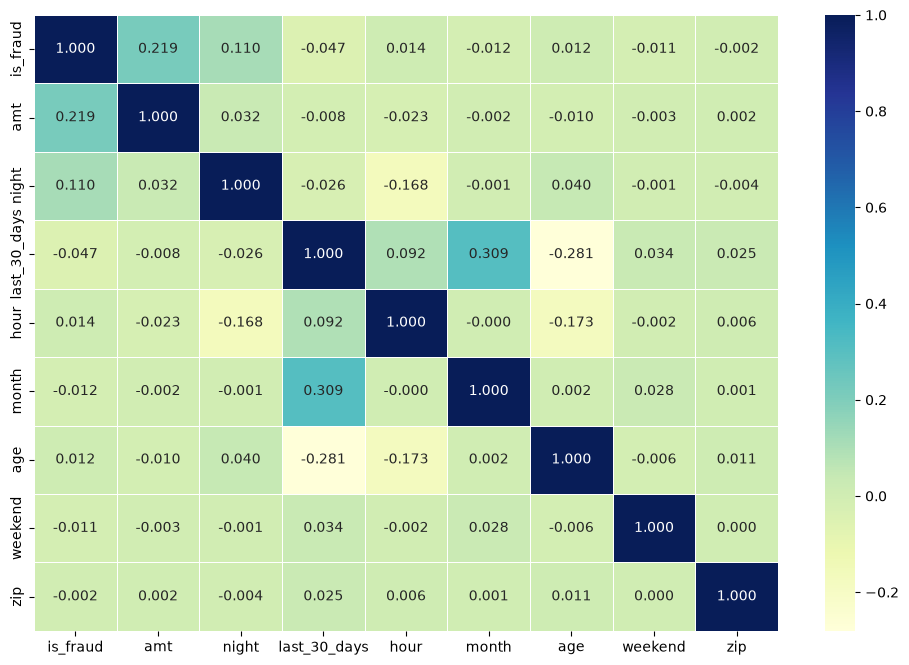

In [26]:
corr_matrix = X_final.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5, fmt= ".3f", cmap="YlGnBu");

In [27]:
X_train = pd.get_dummies(X_train)

Encoding `category` feature.

## Oversampling Training Data

In [28]:
sm = SMOTE()
X_train, y_train = sm.fit_resample(X_train, y_train)

## Train the Model

In [ ]:
model = RandomForestClassifier(
    n_estimators=80,      
    max_depth=12,         
    min_samples_leaf=5,   
    random_state=42
)
model.fit(X_train, y_train)

## Prepare Test Data

In [30]:
y = test
y['hour'] = pd.to_datetime(test.trans_date_trans_time).dt.hour
y['night'] = 0
y.loc[y.hour < 4, 'night'] = 1
y.loc[y.hour > 21, 'night'] = 1
y['month'] = pd.to_datetime(test.trans_date_trans_time).dt.month
y['day'] = pd.to_datetime(test.trans_date_trans_time).dt.dayofweek
y['weekend'] = 0
y.loc[y.day == 0, 'weekend'] = 1
y.loc[y.day == 6, 'weekend'] = 1
y['age'] = dt.date.today().year - pd.to_datetime(test.dob).dt.year
y = y.groupby('cc_num').apply(transactionsInLast30Days)
X_test = y[['category', 'amt', 'night', 'last_30_days', 'hour', 'month', 'age', 'weekend', 'zip']]
X_test = pd.get_dummies(X_test)
y_test = y.is_fraud

## Classification Report

In [31]:
y_pred = model.predict(X_test)
print('Classification report:\n', classification_report(y_test, y_pred))

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.34      0.86      0.49      2145

    accuracy                           0.99    555719
   macro avg       0.67      0.92      0.74    555719
weighted avg       1.00      0.99      0.99    555719



## Confusion Matrix

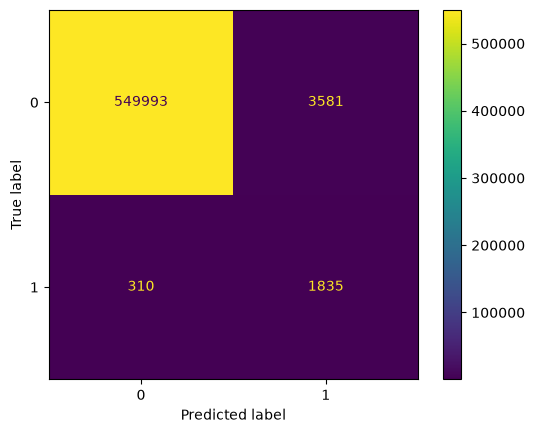

In [32]:
ConfusionMatrixDisplay.from_estimator(estimator=model, X=X_test, y=y_test);

# Saving the Model

### Pickle

In [ ]:
pickle.dump(model, open("model.pkl", "wb"))

### Onnx

In [ ]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Define input structure (22 features)
initial_type = [('float_input', FloatTensorType([None, 22]))]
onnx_model = convert_sklearn(model, initial_types=initial_type)

with open("model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())
